In [20]:
%pip install fastai "fastcore<2.0.0"

  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of python-fasthtml to determine which version is compatible with other requirements. This could take a while.
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 4.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.0/661.0 kB 5.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.1/792.1 kB 9.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 675.5/675.5 kB 6.5 MB/s  0:00:00
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached starlette-1.3.1-py3-none-any.whl (73 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.5 MB/s

In [2]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

In [22]:
def is_cat(x): return x[0].isupper()

In [23]:
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

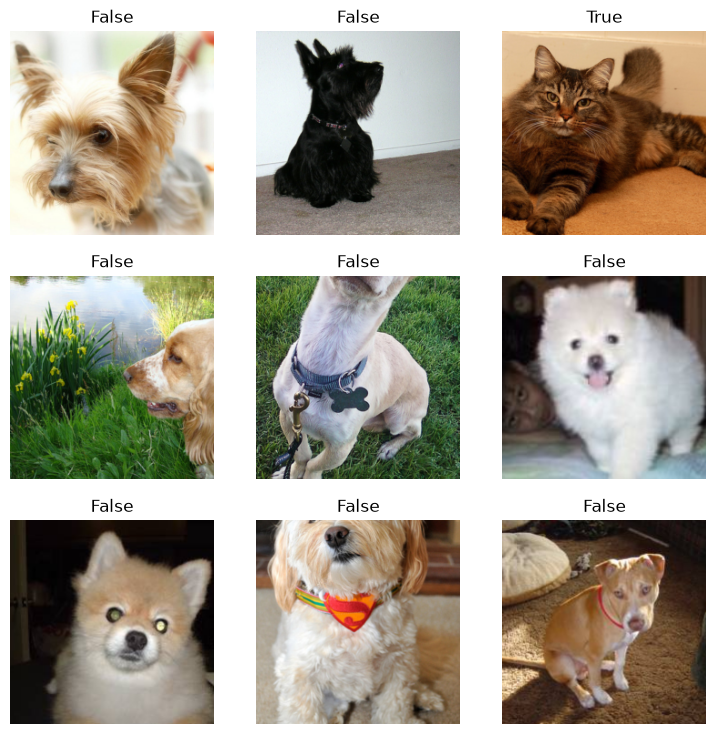

In [24]:
dls.show_batch()

In [25]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/asd/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100.0%


In [26]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.155117,0.022097,0.007442,01:17


epoch,train_loss,valid_loss,error_rate,time
0,0.062351,0.014842,0.004736,01:36


In [3]:
uploader = SimpleNamespace(data = ['../test_data/1.jpg', '../test_data/2.jpg'])

Is this a cat?: False.
Probability it's a cat: 0.000023


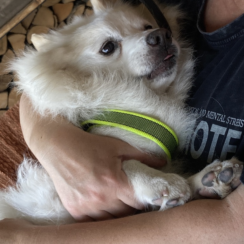

In [37]:
img = PILImage.create(uploader.data[0])
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")
Resize(244)(img)

In [34]:
img = PILImage.create(uploader.data[1])
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: True.
Probability it's a cat: 0.548778
